In [31]:
import torch
import torch.nn as nn

from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

In [32]:
# Project Paths
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "mobilenet_plant_disease_new.pth"
DATASET_PATH = BASE_DIR / "data" / "color"

print("Base Directory:", BASE_DIR)
print("Model Path:", MODEL_PATH)
print("Dataset Path:", DATASET_PATH)

Base Directory: c:\Users\bhall\OneDrive\Desktop\project
Model Path: c:\Users\bhall\OneDrive\Desktop\project\models\mobilenet_plant_disease_new.pth
Dataset Path: c:\Users\bhall\OneDrive\Desktop\project\data\color


In [33]:
from torchvision.datasets import ImageFolder

# Load dataset only to get class names
dataset = ImageFolder(DATASET_PATH)

# Get class names
class_names = dataset.classes

print("Total Classes:", len(class_names))
print("\nFirst 10 Classes:")
print(class_names[:10])

Total Classes: 38

First 10 Classes:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


In [34]:
# Create MobileNetV2 architecture
mobilenet = models.mobilenet_v2(weights=None)

# Replace the classifier exactly as in Notebook 3
mobilenet.classifier[1] = nn.Linear(
    mobilenet.classifier[1].in_features,
    len(class_names)
)

# Load trained weights
mobilenet.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))

# Put model in evaluation mode
mobilenet.eval()

print("✅ Trained MobileNetV2 loaded successfully!")

✅ Trained MobileNetV2 loaded successfully!


In [36]:
# Image preprocessing (same as training)
prediction_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Prediction transform created successfully!")

✅ Prediction transform created successfully!


In [37]:
# Select one sample image from the dataset
image_path = dataset.samples[0][0]

print("Selected Image:")
print(image_path)

Selected Image:
c:\Users\bhall\OneDrive\Desktop\project\data\color\Apple___Apple_scab\0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG


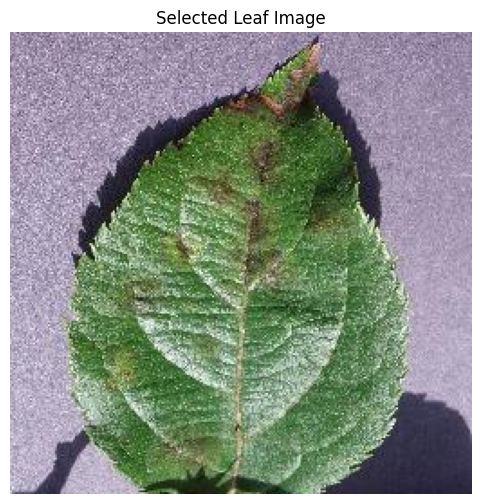

In [38]:
# Open the image
image = Image.open(image_path)

# Display the image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Selected Leaf Image")
plt.axis("off")
plt.show()

In [39]:
# Apply transforms
input_tensor = prediction_transform(image)

# Add batch dimension
input_batch = input_tensor.unsqueeze(0)

print("Input Tensor Shape:", input_batch.shape)

Input Tensor Shape: torch.Size([1, 3, 224, 224])


In [40]:
# Disable gradient calculation (faster inference)
with torch.no_grad():

    # Get model output
    outputs = mobilenet(input_batch)

    # Get prediction
    _, predicted = torch.max(outputs, 1)

# Convert prediction index to class name
predicted_class = class_names[predicted.item()]

print("Predicted Class:", predicted_class)

Predicted Class: Apple___Apple_scab


In [41]:
# Actual class from dataset
actual_class = class_names[dataset.samples[0][1]]

print("Actual Class   :", actual_class)
print("Predicted Class:", predicted_class)

if actual_class == predicted_class:
    print("\n✅ Prediction is Correct!")
else:
    print("\n❌ Prediction is Incorrect!")

Actual Class   : Apple___Apple_scab
Predicted Class: Apple___Apple_scab

✅ Prediction is Correct!


In [42]:
# Convert model outputs into probabilities
probabilities = torch.softmax(outputs, dim=1)

# Get highest probability
confidence = probabilities[0][predicted.item()].item() * 100

print("🌿 Predicted Disease :", predicted_class)
print(f"🎯 Confidence : {confidence:.2f}%")

🌿 Predicted Disease : Apple___Apple_scab
🎯 Confidence : 50.00%
